In [1]:
import pandas as pd
import numpy as np
import random

In [2]:
np.random.seed(42)

In [3]:
restaurants = ["Dominos", "KFC", "Burger King", "Pizza Hut", "McDonalds"]

data = []

for i in range(300):
    order = {
        "order_id": i+1,
        "restaurant": random.choice(restaurants),
        "order_value": np.random.randint(100, 1000),
        "delivery_time": np.random.randint(10, 60),
        "customer_rating": round(np.random.uniform(1, 5), 1)
    }


    if np.random.rand() < 0.05:
        order["delivery_time"] = None

    data.append(order)

df = pd.DataFrame(data)


In [4]:
df.head()

,order_id,restaurant,order_value,delivery_time,customer_rating
0,1,KFC,202,38.0,1.7
1,2,Dominos,120,48.0,2.8
2,3,KFC,558,33.0,2.3
3,4,KFC,230,31.0,1.2
4,5,KFC,513,47.0,1.0


In [6]:
df["delivery_time"].fillna(df["delivery_time"].mean(), inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_2224\423463607.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["delivery_time"].fillna(df["delivery_time"].mean(), inplace=True)


0      38.0
1      48.0
2      33.0
3      31.0
4      47.0
       ... 
295    40.0
296    54.0
297    26.0
298    55.0
299    10.0
Name: delivery_time, Length: 300, dtype: float64

In [7]:
df.head()

,order_id,restaurant,order_value,delivery_time,customer_rating
0,1,KFC,202,38.0,1.7
1,2,Dominos,120,48.0,2.8
2,3,KFC,558,33.0,2.3
3,4,KFC,230,31.0,1.2
4,5,KFC,513,47.0,1.0


In [8]:
df


,order_id,restaurant,order_value,delivery_time,customer_rating
0,1,KFC,202,38.0,1.7
1,2,Dominos,120,48.0,2.8
2,3,KFC,558,33.0,2.3
3,4,KFC,230,31.0,1.2
4,5,KFC,513,47.0,1.0
...,...,...,...,...,...
295,296,Burger King,126,40.0,4.5
296,297,Pizza Hut,367,54.0,3.7
297,298,Pizza Hut,784,26.0,2.7
298,299,Burger King,733,55.0,1.2


In [9]:
df['delivery_time']=np.where(df['delivery_time']<0,df['delivery_time'].mean(),df['delivery_time'])

In [10]:
revnue=df.groupby('restaurant')['order_value'].sum().reset_index()

In [11]:
revnue

,restaurant,order_value
0,Burger King,34118
1,Dominos,29510
2,KFC,30251
3,McDonalds,35768
4,Pizza Hut,35597


In [12]:
performance=df.groupby('restaurant').agg({
    'customer_rating': 'mean',
    'delivery_time': 'mean'
}).reset_index()


poor_restaurants = performance[
    (performance["customer_rating"] < 3) &
    (performance["delivery_time"] > 30)
]

poor_restaurants

,restaurant,customer_rating,delivery_time
1,Dominos,2.950980,31.297872
2,KFC,2.777358,33.288462
4,Pizza Hut,2.967692,36.216667


In [14]:
delivery=df['delivery_time'].values
p50=np.percentile(delivery,50)
p75=np.percentile(delivery,75)
p90=np.percentile(delivery,90)

print('Median',p50)
print('75th percentile',p75)
print('90th percentile',p90)

Median nan
75th percentile nan
90th percentile nan


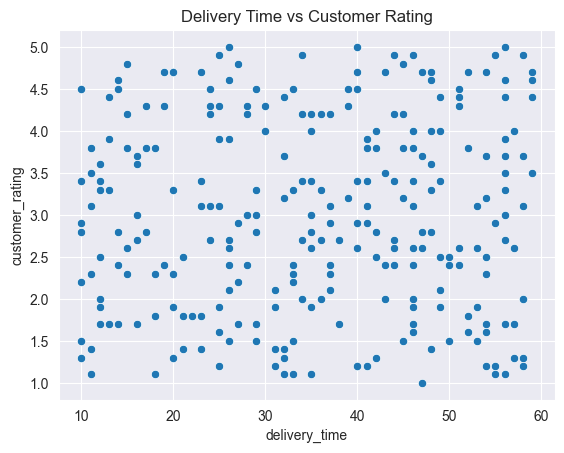

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='delivery_time', y='customer_rating',data=df)
plt.title('Delivery Time vs Customer Rating')
plt.show()

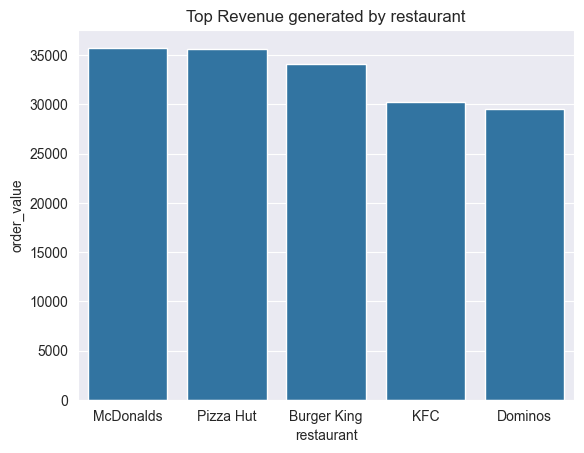

In [16]:
top_rev=revnue.sort_values(by='order_value', ascending=False)
sns.barplot(x='restaurant', y='order_value', data=top_rev)
plt.title('Top Revenue generated by restaurant')
plt.show()